In [190]:
%run Wiskunde_II_Portfolio.ipynb

Mean Absolute Error: 595.46 KG CO2 per jaar
De b0 waarde van de formule is: -2350.145181700008
De coëfficiënten van de formule zijn: [ 1.73285464e-04  4.98609178e-01  1.18860692e+00  1.16404844e-03
  9.86458679e+00  7.85390134e+00  2.60389035e-01 -6.99397625e-02
 -1.89477996e-02 -6.20456615e-02  2.55648583e-02  1.82740247e+01
 -4.38291460e+01  2.87349562e+01 -7.08382423e+01  2.60098606e+03
  4.07599378e+01  7.75197856e+01  2.34372644e+02  1.99102536e+02
  7.48754059e+01  1.64093245e+02  2.31707382e+02  4.22457273e+01
  1.98321551e+02  1.25198165e+02  1.14557057e+02 -2.81997751e+01
 -8.21753719e+00 -1.05615035e+02 -3.60663835e+01  1.95755625e+01
  1.09455860e-01 -1.72127780e+02 -3.15430135e+02  1.32937263e+00
  7.42520108e-02]
Voorspelling: 2232.56 KG CO2 per jaar


C:\Users\schur\AppData\Local\Temp\ipykernel_6228\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [192]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [193]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,km_totaal,aandeel_auto,aandeel_vliegtuig,kantoor_dagen_per_jaar,hoog_uitstoot_gedrag
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,19015.25,0.697653,0.025280,52,14708.18
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,0,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,18952.19,0.803595,0.075102,0,19499.91
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,1,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,26530.39,0.748321,0.023840,52,21750.68
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,17435.82,0.569833,0.072657,104,13736.02
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,5,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,21729.86,0.748586,0.077129,260,21294.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,6383.24,3672.70,3085.83,1254.60,0,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,14396.37,0.443392,0.087147,0,10147.04
1496,964501,54,85.09,45963.45,5,1,18050.72,1907.56,1247.67,907.07,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,22113.02,0.816294,0.041020,52,20771.93
1497,659695,48,71.79,43443.92,5,2,6860.47,1568.27,1051.74,1385.12,0,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,10865.60,0.631394,0.127478,0,11015.83
1498,883394,76,69.02,33158.29,4,1,0.00,2170.89,1978.18,364.76,0,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4513.83,0.000000,0.080809,0,1094.28


In [194]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 38 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   persoon_ID                             1500 non-null   int64  
 1   leeftijd                               1500 non-null   int64  
 2   gewicht_KG                             1500 non-null   float64
 3   jaarsalaris_eu                         1500 non-null   float64
 4   huishouden_grootte                     1500 non-null   int64  
 5   opleiding_niveau                       1500 non-null   int64  
 6   km_auto_per_jaar                       1500 non-null   float64
 7   km_fiets_per_jaar                      1500 non-null   float64
 8   km_ov_per_jaar                         1500 non-null   float64
 9   km_vliegtuig_per_jaar                  1500 non-null   float64
 10  dagen_kantoorwerken_per_week_pro_rato  1500 non-null   int64  
 11  dage

In [195]:
feature_eng_cols = ['km_totaal', 'aandeel_auto', 'aandeel_vliegtuig', 'kantoor_dagen_per_jaar', 'hoog_uitstoot_gedrag']

raw_eng_cols = ['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato']

df_transformed = df_transformed.drop(raw_eng_cols, axis=1)

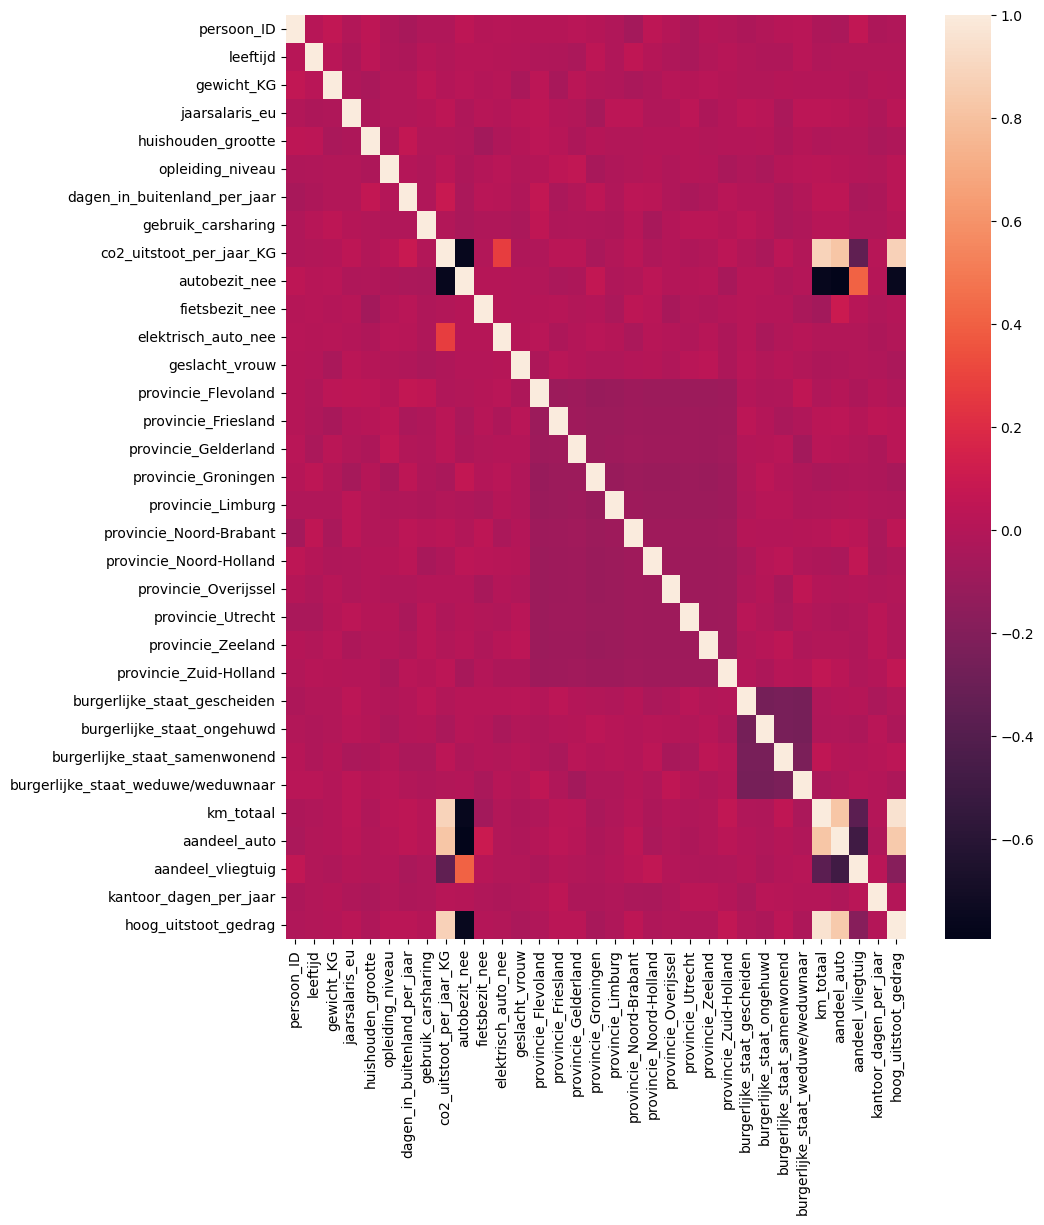

In [196]:
plt.figure(figsize=(10, 12))

sns.heatmap(df_transformed.corr(method='spearman'))

plt.show()

In [ ]:
df[modus_cols]


,geslacht,burgerlijke_staat,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,gebruik_carsharing
0,man,weduwe/weduwnaar,Flevoland,MBO,ja,ja,nee,Nooit
1,vrouw,samenwonend,Overijssel,WO,ja,nee,nee,Heel soms
2,man,samenwonend,Utrecht,HBO,ja,ja,ja,Altijd
3,man,gehuwd,Utrecht,HBO,ja,ja,nee,Heel soms
4,man,ongehuwd,Gelderland,MBO,ja,ja,ja,Nooit
...,...,...,...,...,...,...,...,...
1495,man,weduwe/weduwnaar,Noord-Holland,HBO,ja,ja,nee,Heel soms
1496,man,ongehuwd,Drenthe,MBO,ja,ja,ja,Heel soms
1497,man,weduwe/weduwnaar,Flevoland,HBO,ja,ja,nee,Nooit
1498,man,gehuwd,Drenthe,MBO,nee,ja,nee,Nooit


In [207]:
import numpy as np

modus_cols = ['geslacht', 'burgerlijke_staat', 'provincie', 'opleiding_niveau', 'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']

def eta_squared(categorisch, numeriek):
    groepen = [numeriek[categorisch == c] for c in categorisch.unique()]
    grand_mean = numeriek.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groepen)
    ss_total = ((numeriek - grand_mean)**2).sum()
    return ss_between / ss_total

for i in modus_cols:

    print(eta_squared(df[i], df['co2_uitstoot_per_jaar_KG']))


0.0008489676611990393
0.0022113464361503206
0.005266225248031182
0.0021808560349749003
0.5034053830760082
7.53412339514707e-06
0.09018871376382136
0.0032242970587868084


<Axes: >

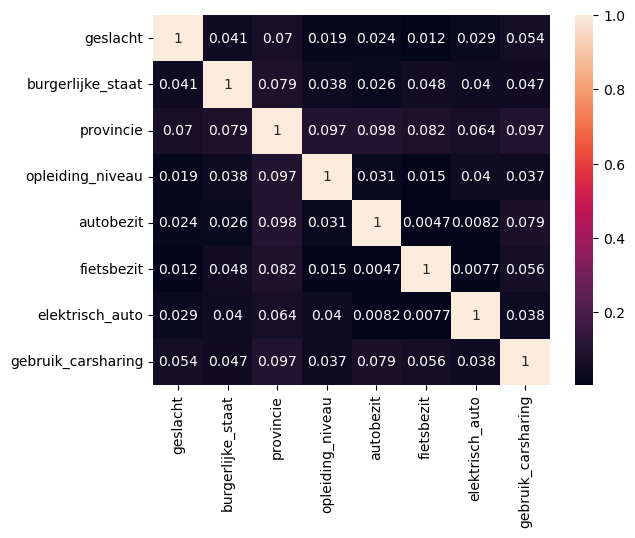

In [221]:
from scipy import stats
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

dicto = {}

for i in modus_cols:
    dicto[i] = {}


    for j in modus_cols:

        dicto[i][j] = cramers_v(df[i], df[j])
        

        

dicto = pd.DataFrame(dicto)

sns.heatmap(dicto, annot=True)

In [223]:
corr_target

,autobezit_nee
autobezit_nee,1.000000
aandeel_vliegtuig,0.535118
provincie_Groningen,0.065742
persoon_ID,0.043983
provincie_Noord-Holland,0.036818
leeftijd,0.017981
gewicht_KG,0.017119
provincie_Zeeland,0.012933
burgerlijke_staat_gescheiden,0.012765
burgerlijke_staat_ongehuwd,0.012765


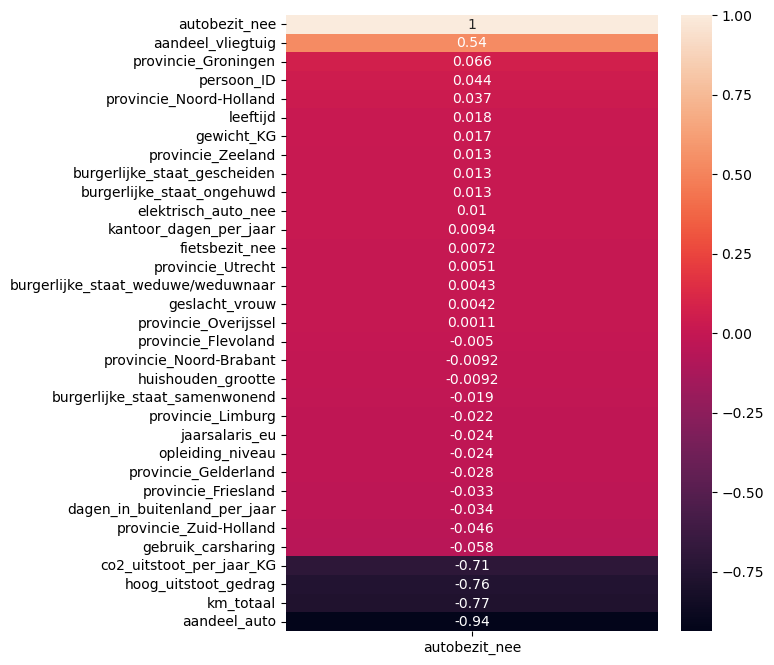

In [222]:
corr_target = df_transformed.corrwith(df_transformed['autobezit_nee']).sort_values(ascending=False).to_frame(name='autobezit_nee')

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True)

plt.show()

In [198]:
X = df_transformed.drop(['co2_uitstoot_per_jaar_KG', 'persoon_ID'], axis=1)
y = df_transformed['co2_uitstoot_per_jaar_KG']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.25)





In [199]:
from sklearn.linear_model import LinearRegression


In [200]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_val, y_val)

0.9004546807240775

In [201]:
mediaan_cols

['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [202]:
print('hallo')
_

hallo


['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [203]:
mediaan_cols.remove('co2_uitstoot_per_jaar_KG')

scaler = StandardScaler()

X_train[mediaan_cols] = scaler.fit_transform(X_train[_])
X_val[mediaan_cols] = scaler.transform(X_val[_])
X_test[mediaan_cols] = scaler.transform(X_test[_])



KeyError: "['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato'] not in index"

In [ ]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_test, y_test)

0.9345731899434266